# Low-Rank Covariance Polynomial Chaos

We revisit the wavy one-dimensional regression toy problem and constrain `pypolymix` to learn a low-rank Gaussian over every polynomial chaos coefficient.
Compared to `full_covariance.ipynb`, this variant mirrors the same pipeline but relies on `LowRankGaussianGroup` to capture the dominant correlations with far fewer parameters.


In [1]:
# Import statements
import matplotlib.pyplot as plt
import torch

from pypolymix.parameter_groups import LowRankGaussianGroup
from pypolymix.surrogate_models import PolynomialChaosExpansion
from pypolymix import StochasticModel

In [2]:
# Set random seed
_ = torch.manual_seed(1234)

In [3]:
# Generate synthetic data
n_train = 32
noise = 0.02

x_train = torch.rand(n_train, 1)
x_train[:n_train // 2] *= -1
x_train[n_train // 2:] += 1
x_train /= 2

eps1 = noise * torch.randn(n_train, 1)
eps2 = noise * torch.randn(n_train, 1)
eps3 = noise * torch.randn(n_train, 1)

y_train = x_train + 0.3 * torch.sin(2. * torch.pi * (x_train + eps1)) + 0.3 * torch.sin(4. * torch.pi * (x_train + eps2)) + eps3

We sample `n_train = 32` inputs split evenly across the negative and positive halves of the domain, blend two sinusoids with a linear drift, and add small Gaussian noise.

A quick scatter plot sets expectations for the frequency content and the observation noise that the surrogate must ultimately match.


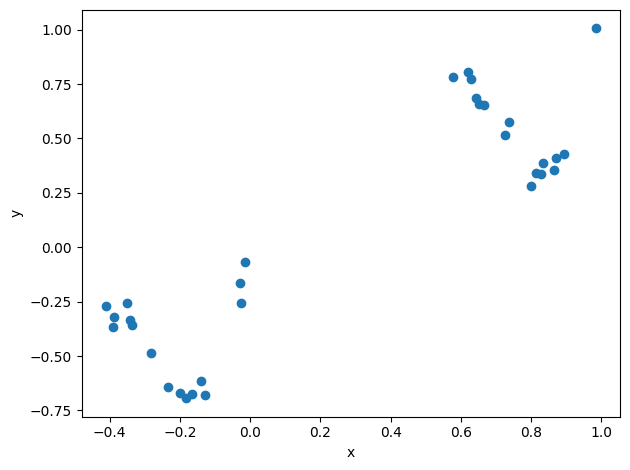

In [4]:
# Plot synthetic data
_, ax = plt.subplots()
ax.scatter(x_train, y_train)
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()

A degree-7 `PolynomialChaosExpansion` is flexible enough to follow the multi-frequency signal while staying cheap to evaluate, so thousands of stochastic forward passes remain affordable.


In [5]:
# Create a surrogate model
degree = 7
surrogate_model = PolynomialChaosExpansion(num_inputs=1, num_outputs=1, degree=degree)
num_params = surrogate_model.num_params()
print(f"This model has {num_params} parameters")

This model has 8 parameters


`LowRankGaussianGroup` wraps the coefficient vector with a low-rank plus diagonal covariance, striking a balance between capturing correlations and keeping the number of learnable parameters manageable. Compared to the full covariance example, which has `d * (d + 1) / 2 = 36` latent parameters to learn, the low-rank approximation learns only `r * (d + 1) = 16`.


In [6]:
# Create parameter groups
parameters = LowRankGaussianGroup("params", surrogate_model.num_params(), rank=2)

`StochasticModel` stitches the deterministic surrogate and parameter group together, handles coefficient sampling, and exposes helpers such as `distribution_loss()` for regularising the posterior.


In [7]:
# Create stochastic model
model = StochasticModel(surrogate_model, parameters)
print(f"Created stochastic model with {model.num_params()} parameters")

Created stochastic model with 8 parameters


We mirror the other tutorials by collecting the standard hyperparameters (`num_samples`, `num_epochs`, `lr`, `weight_decay`, `weight_factor`), introducing a learnable `log_tau` so the data term becomes $\tau \cdot \text{MSE}$, and driving AdamW with a `OneCycleLR` schedule.


In [8]:
# Training options
lr = 1e-3             # Learning rate
weight_decay = 1e-4   # Weight decay for AdamW
weight_factor = 5e-3  # Weight factor for distribution loss
num_epochs = 10000    # Number of epochs
num_samples = 100     # Number of parameter samples per epoch

# Optimizer: AdamW
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

# Loss
loss_fn = torch.nn.MSELoss(reduction="sum")

# Scheduler: OneCycleLR
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=10 * lr,
    total_steps=num_epochs
)


Each epoch draws `num_samples` coefficient realizations, evaluates the surrogate on all training inputs, aligns the target tensor so that `torch.nn.MSELoss` can operate in batch, and mixes the resulting data term with the distribution regularizer.

We keep a short list of metrics and let `tabulate` render the epoch, learning rate, and loss components in a compact table (falling back to the plain text formatter if `tabulate` is unavailable).


In [9]:
# Train the stochastic model
for epoch in range(num_epochs):
    optimizer.zero_grad()

    # Draw posterior samples and evaluate the surrogate on the training set
    params = model.sample_parameters(num_samples=num_samples)
    predictions = surrogate_model(x_train, params)

    # Compute losses
    target = y_train.unsqueeze(0).expand_as(predictions)
    data_loss = loss_fn(predictions, target) / num_samples
    distribution_loss = model.distribution_loss()
    total_loss = data_loss + weight_factor * distribution_loss

    # Backpropagation + optimizer + scheduler steps
    total_loss.backward()
    optimizer.step()
    scheduler.step()

    # Logging
    if (epoch + 1) % 1000 == 0:
        current_lr = scheduler.get_last_lr()[0]
        print(
            f"Epoch {epoch + 1:5d} | "
            f"learning rate = {current_lr:.6f} | "
            f"data loss = {data_loss.item():.4f} | "
            f"distribution loss = {distribution_loss.item():.4f} | "
            f"total loss = {total_loss.item():.4f}"
        )

Epoch  1000 | learning rate = 0.002801 | data loss = 2.8142 | distribution loss = 8.5511 | total loss = 2.8570
Epoch  2000 | learning rate = 0.007603 | data loss = 0.6009 | distribution loss = 13.9860 | total loss = 0.6709
Epoch  3000 | learning rate = 0.010000 | data loss = 0.3216 | distribution loss = 16.7608 | total loss = 0.4054
Epoch  4000 | learning rate = 0.009504 | data loss = 0.2348 | distribution loss = 18.6548 | total loss = 0.3280
Epoch  5000 | learning rate = 0.008116 | data loss = 0.2173 | distribution loss = 19.7183 | total loss = 0.3159
Epoch  6000 | learning rate = 0.006110 | data loss = 0.2115 | distribution loss = 20.6997 | total loss = 0.3150
Epoch  7000 | learning rate = 0.003885 | data loss = 0.2015 | distribution loss = 21.0625 | total loss = 0.3068
Epoch  8000 | learning rate = 0.001881 | data loss = 0.1964 | distribution loss = 21.0526 | total loss = 0.3017
Epoch  9000 | learning rate = 0.000494 | data loss = 0.1971 | distribution loss = 21.2643 | total loss = 

After training we put the model in `eval()` mode, create a dense grid of test inputs, and draw stochastic forward passes inside `torch.no_grad()` so the predictive distribution over the domain can be summarized.


In [10]:
# Evaluate the model
model.eval()
with torch.no_grad():
    x_test = torch.linspace(-0.5, 1, 1001).unsqueeze(1)
    y_test = model(x_test, num_samples=100)

We summarize the sampled predictions by plotting the sample mean and the central 98% interval (1%-99% quantiles), then overlay the noisy observations to visually assess how well the stochastic PCE tracks the signal.


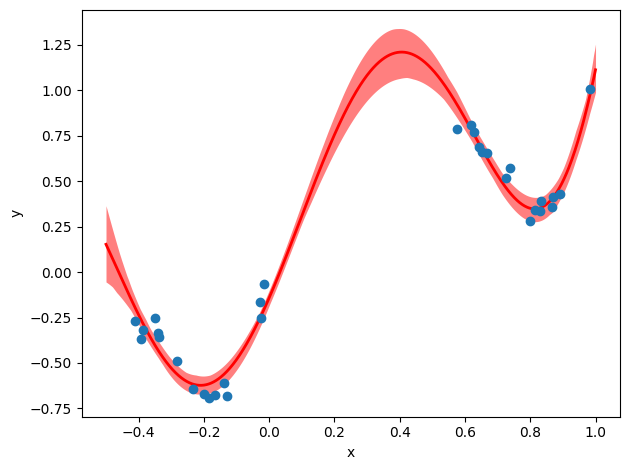

In [11]:
# Plot prediction
_, ax = plt.subplots()
Q_test = torch.quantile(y_test, torch.tensor([0.01, 0.99]), axis=0)
X_plot = x_test.squeeze(-1)
Q_plot = Q_test.squeeze(-1)
ax.fill_between(X_plot, Q_plot[0], Q_plot[-1], color="red", alpha=0.5, linewidth=0)
M_plot = y_test.mean(axis=0).squeeze(-1)
ax.plot(X_plot, M_plot, color="red", linewidth=2)
ax.scatter(x_train, y_train, zorder=99)
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()

Finally we inspect the posterior covariance between polynomial chaos coefficients to understand how uncertainty couples the basis functions. A heatmap highlights dominant directions or nearly deterministic weights.


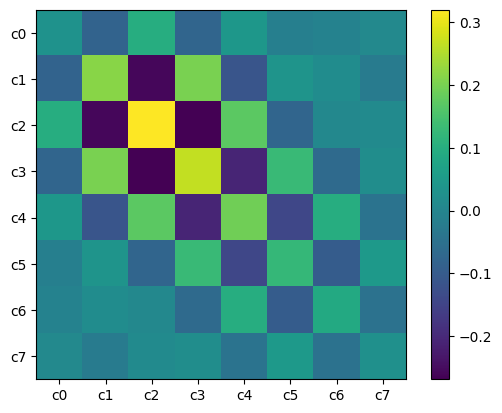

In [12]:
# Inspect the posterior covariance
with torch.no_grad():
    gaussian_group = model.parameter_groups[0]
    posterior = gaussian_group.variational_distribution()
    covariance = posterior.covariance_matrix.detach().cpu()
    
# Plot correlation matrix
plt.imshow(covariance)
plt.colorbar()

num_params = surrogate_model.num_params()
plt.xticks(range(num_params), [f"c{i}" for i in range(num_params)])
plt.yticks(range(num_params), [f"c{i}" for i in range(num_params)])

plt.show()